### ORBIT Example - Installation Schedule

This example shows how to use the action log and visualize the installation schedule. 

In [1]:
import sys
sys.path.insert(0, '/Users/sbredenk/Repos/ORBIT_natl_gaps')
from ORBIT.phases.design import ElectricalDesign

from ORBIT import ProjectManager, ParametricManager
import pandas as pd
import textwrap

import numpy as np

import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt

In [2]:

sched_overlap = pd.read_csv('South Fork.csv')

sched_overlap.head()

,Unnamed: 0,cost_multiplier,agent,action,duration,cost,level,time,phase,phase_name,location,site_depth,hub_height
0,0,1.0,WTIV,Mobilize,168.0,3500000.0,ACTION,0.0,MonopileInstallation,NaN,NaN,NaN,NaN
1,1,0.5,Feeder 0,Mobilize,72.0,112500.0,ACTION,0.0,MonopileInstallation,NaN,NaN,NaN,NaN
2,2,0.5,Feeder 1,Mobilize,72.0,112500.0,ACTION,0.0,MonopileInstallation,NaN,NaN,NaN,NaN
3,3,NaN,Feeder 0,Fasten Monopile,12.0,37500.0,ACTION,12.0,MonopileInstallation,MonopileInstallation,NaN,NaN,NaN
4,4,NaN,Feeder 0,Fasten Transition Piece,8.0,25000.0,ACTION,20.0,MonopileInstallation,MonopileInstallation,NaN,NaN,NaN



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copySettingWithCopyWarning: c:\Users\sbredenk\.conda\envs\orbit-sophie\lib\site-packages\pandas\core\indexing.py:1817

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copyUserWarning: c:\Users\sbredenk\.conda\envs\orbit-sophie\lib\site-packages\ipykernel_launcher.py:31
FixedFormatter should only be used together with FixedLocator

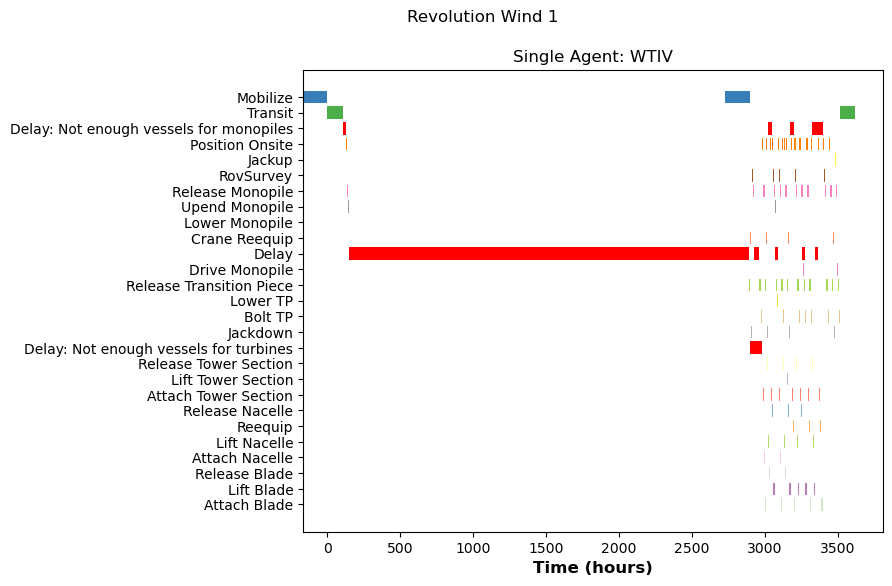


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copySettingWithCopyWarning: c:\Users\sbredenk\.conda\envs\orbit-sophie\lib\site-packages\pandas\core\indexing.py:1817

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copyUserWarning: c:\Users\sbredenk\.conda\envs\orbit-sophie\lib\site-packages\ipykernel_launcher.py:31
FixedFormatter should only be used together with FixedLocator

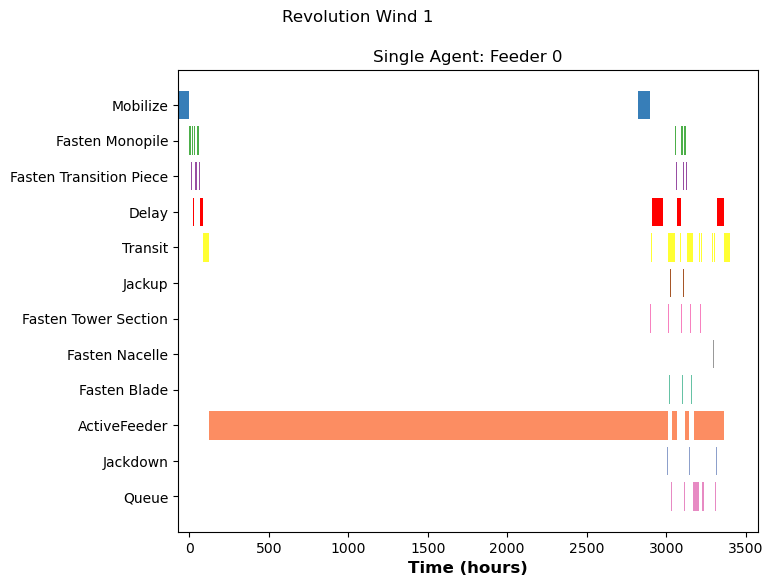


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copySettingWithCopyWarning: c:\Users\sbredenk\.conda\envs\orbit-sophie\lib\site-packages\pandas\core\indexing.py:1817

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copyUserWarning: c:\Users\sbredenk\.conda\envs\orbit-sophie\lib\site-packages\ipykernel_launcher.py:31
FixedFormatter should only be used together with FixedLocator

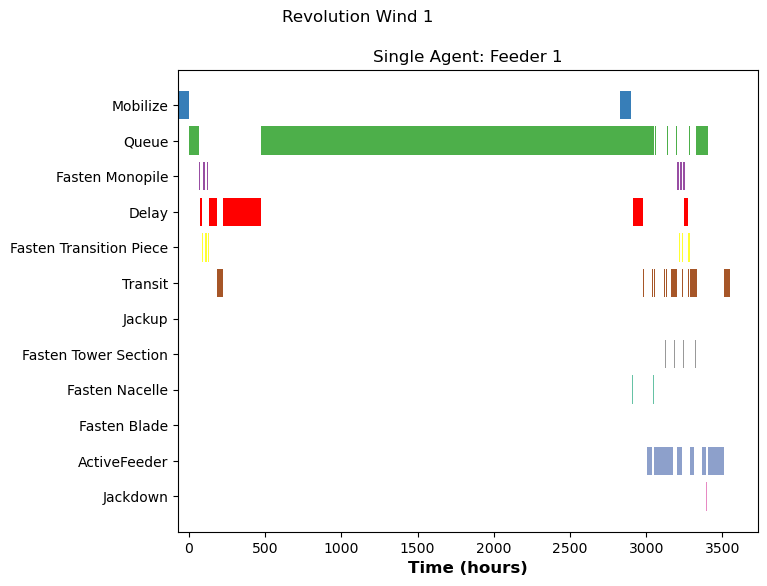

In [3]:
#print(agents)

def single_agent_df(df, agent=None, verbose=False):

    df_s = df[df['agent'].str.contains(agent)]
    if verbose:
        display(df_s)
    return df_s

def plot_single_df(df, agent, phases, xlim=None, savePlot=True, verbose=False):

    wrapped_phases_dic = [textwrap.fill(p, width=48) for p in phases]

    fig, ax = plt.subplots(1, figsize=(10,6))
    fig.suptitle("Revolution Wind 1")

    ax.barh(y=df['action'],
           width=df['duration'],
           left=df['time'] - df['duration'],
           color=df.color)

    ax.set_title('Single Agent: ' + agent,fontsize=12)

    num_x_labels = 5
    day_spacing = int(((df['time'].max() - df['time'].min())/24)/num_x_labels)
    #xticks = np.arange(0, (df['time'].max()+1)/24, day_spacing)

    #ax.set_xticks(xticks)
    ax.set_xlabel("Time (hours)", fontdict=dict(weight='bold'), fontsize=12)

    ax.set_yticklabels(wrapped_phases_dic)
    plt.gca().invert_yaxis()
    fig.subplots_adjust(left=0.32)

    plt.show()
    #if savePlot:
    #    fig.savefig(os.path.join(agent + "_phases"))

agent = ['WTIV', 'Feeder 0', 'Feeder 1']

color_sns_hex=(sns.color_palette("Set1").as_hex()
                + sns.color_palette("Set2").as_hex()
                + sns.color_palette("Set3").as_hex()
)

savePlots = False

for a in agent:
    df_single = single_agent_df(sched_overlap, agent=a, verbose=False)
    phases = df_single['action'].unique()

    def color(row):
        c_dict2 = {phases[j]: color_sns_hex[j+1] for j in range(len(phases))}
        #print(c_dict2)
        return c_dict2[row['action']]

    df_single_plot = df_single
    df_single_plot['color'] = df_single_plot.apply(color, axis=1)

    # make delays red
    df_single_plot.loc[sched_overlap["action"].str.contains('Delay'), "color"] = '#FF0000'

    plot_single_df(df_single_plot, agent=a, phases=phases, savePlot=savePlots, verbose=False)


['WTIV' 'Feeder 0' 'Feeder 1']


FixedFormatter should only be used together with FixedLocator

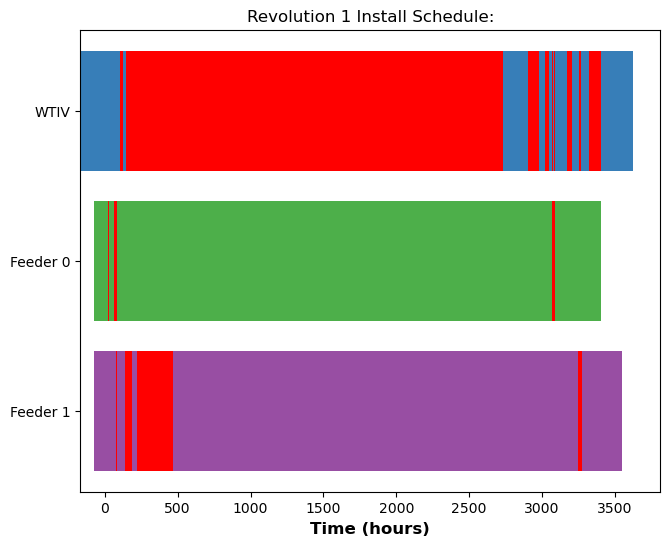

In [4]:
# Plot logic
plot_based_on = 'agent'

agents = sched_overlap['agent'].unique()

print(agents)

wrapped_agents_dic = [textwrap.fill(a, width=16) for a in agents]

color_sns_hex=sns.color_palette("Set1").as_hex() + sns.color_palette("Set2").as_hex()

def color(row):

    c_dict = {agents[i]: color_sns_hex[i+1] for i in range(len(agents))}
    #print(c_dict)
    return c_dict[row['agent']]

df2_plot = sched_overlap
df2_plot['color'] = df2_plot.apply(color, axis=1)
# make delays red
df2_plot.loc[df2_plot["action"].str.contains('Delay'), "color"] = '#FF0000'

#if saveCSV:
#    df2_plot.to_csv(os.path.join(OUTDIR, "Mod_" + input_filename))

fig, ax = plt.subplots(1, figsize=(10,6))
#fig.suptitle("Aikido Floating Offshore Project: CA")

ax.barh(y=df2_plot[plot_based_on],
           width=df2_plot['duration'],
           left=df2_plot['time'] - df2_plot['duration'],
           color=df2_plot.color)

ax.set_title('Revolution 1 Install Schedule:')

num_x_labels = 5
#day_spacing = int(((df2_plot['end_date'].max() - df2_plot['start_date'].min()).days)/num_x_labels)
#xticks = np.arange(0, df2_plot['days_to_end'].max()+1, day_spacing)
#ax.set_xticks(xticks)

ax.set_xlabel("Time (hours)", fontdict=dict(weight='bold'), fontsize=12)

ax.set_yticklabels(wrapped_agents_dic)
plt.gca().invert_yaxis()
fig.subplots_adjust(left=0.32)

plt.show()